# Analyse des sentiments avec Word2Vec et Deep Learning — CORRECTION

Dans le notebook 23, nous avons utilisé **TF-IDF** pour représenter les tweets, puis un Deep learning pour les classifier.

Dans ce notebook, nous explorons deux approches plus avancées :

| Approche | Représentation | Modèle | Avantages |
|---|---|---|---|
| TF-IDF + Deep learning (notebook 23) | Fréquence des mots (~14000 dims) | Réseau dense | Simple |
| **Word2Vec + Deep learning** | Moyenne des embeddings (300 dims) | Réseau dense | Sémantique des mots |
| **RNN + Word2Vec** | Séquence d'embeddings (300 dims) | RNN | Contexte et ordre |

**Pourquoi les embeddings sont-ils meilleurs que TF-IDF ?**
- "heureux" et "content" auront des vecteurs proches (sémantique)
- Dimensionnalité fixe et réduite : 300 vs ~14000 pour TF-IDF
- Le RNN capture en plus l'**ordre** et le **contexte** des mots

In [1]:
!pip install gensim -q

# Importation des packages

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

from gensim.models import KeyedVectors
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Importation des données

Ajoutez un raccourci de ces dossiers à votre Google Drive :

- Tweets nettoyés : https://drive.google.com/drive/folders/1uj-BnUzSHJOHuojQ9q8q53DN0EGiPpcl?usp=sharing
- Modèle Word2Vec : https://drive.google.com/drive/folders/1e6eRSPuZz3A3BXPVbggKHC_9XKU0MWAW?usp=sharing

In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [26]:
df = pd.read_csv('/content/drive/MyDrive/RNN_sentiment_dataset/cleaned_tweets.csv')
df.head()

,label,tweet
0,0,awww bummer shoulda got david carr third day
1,0,upset cannot update facebook texting might cry...
2,0,dived many times ball managed save rest bounds
3,0,whole body feels itchy like fire
4,0,behaving mad cannot see


In [27]:
df.shape

(1590739, 2)

In [36]:
df = pd.concat([df.iloc[-50000:, :], df.iloc[:50000, :]])

In [37]:
print(df['label'].value_counts())
print(df.shape)

label
1    50000
0    50000
Name: count, dtype: int64
(100000, 2)


# Chargement du modèle Word2Vec

Nous utilisons le modèle pré-entraîné de Google (vu dans le notebook 25) :
- Entraîné sur 100 milliards de mots (Google News)
- 3 millions de mots
- Vecteurs de 300 dimensions

In [38]:
path_word2vec = '/content/drive/MyDrive/embeddings/GoogleNews-vectors-negative300.bin'
word2vec_model = KeyedVectors.load_word2vec_format(path_word2vec, binary=True)
print(f"Modèle chargé : {len(word2vec_model.key_to_index)} mots, dimension {word2vec_model.vector_size}")

Modèle chargé : 3000000 mots, dimension 300


---
# Partie 1 : Word2Vec + Deep learning

## Représentation par moyenne des embeddings (Mean Pooling)

Pour chaque tweet, nous :
1. Divisons le texte en mots
2. Récupérons le vecteur Word2Vec de chaque mot connu
3. Calculons la **moyenne** de tous ces vecteurs → 1 vecteur de 300 dims

```
tweet : "great movie loved it"
         ↓        ↓      ↓    ↓
W2V : [v_great] [v_movie] [v_loved] [v_it]
                      ↓
              MOYENNE → vecteur 300 dims
```

In [39]:
def tweet_to_embedding(tweet, model, embed_dim=300):
    """
    Convertit un tweet en vecteur d'embedding par moyenne des vecteurs de ses mots.

    Args:
        tweet (str): Le tweet nettoyé
        model: Le modèle Word2Vec (KeyedVectors)
        embed_dim (int): Dimension des embeddings

    Returns:
        np.ndarray: Vecteur de dimension embed_dim
    """
    words = str(tweet).split()

    # Récupérer les vecteurs pour les mots présents dans le vocabulaire W2V
    vectors = [model.get_vector(word) for word in words if word in model.key_to_index]

    if len(vectors) == 0:
        return np.zeros(embed_dim)

    # Retourner la moyenne des vecteurs
    return np.mean(vectors, axis=0)

In [40]:
# Test de la fonction
test_vec = tweet_to_embedding("great movie loved it", word2vec_model)
print(f"Forme du vecteur : {test_vec.shape}")
print(f"5 premières valeurs : {test_vec[:5]}")

Forme du vecteur : (300,)
5 premières valeurs : [ 0.09289551  0.00040007 -0.00723267  0.19702148 -0.01275635]


## Application au jeu de données

In [41]:
%%time
X_embed = np.array([tweet_to_embedding(t, word2vec_model) for t in df['tweet']])
y = df['label'].values

CPU times: user 3.57 s, sys: 259 ms, total: 3.83 s
Wall time: 3.83 s


In [42]:
print(f"Forme de X_embed : {X_embed.shape}")
print(f"Forme de y : {y.shape}")
print(f"Distribution des classes : {dict(zip(*np.unique(y, return_counts=True)))}")

Forme de X_embed : (100000, 300)
Forme de y : (100000,)
Distribution des classes : {np.int64(0): np.int64(50000), np.int64(1): np.int64(50000)}


## Séparation entraînement / test

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X_embed, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (80000, 300), Test: (20000, 300)


## Création des générateurs

In [44]:
class CustomDataset(Dataset):
    def __init__(self, x, y):
        self.input = x
        self.output = y

    def __len__(self):
        return len(self.output)

    def __getitem__(self, idx):
        return self.input[idx], self.output[idx]

In [45]:
x_training = CustomDataset(
    torch.FloatTensor(np.float32(X_train)),
    torch.FloatTensor(np.expand_dims(np.float32(y_train), axis=-1))
)
x_testing = CustomDataset(
    torch.FloatTensor(np.float32(X_test)),
    torch.FloatTensor(np.expand_dims(np.float32(y_test), axis=-1))
)

dataloader_train = DataLoader(x_training, batch_size=64, shuffle=True)
dataloader_test = DataLoader(x_testing, batch_size=64, shuffle=False)

In [46]:
for x, y_batch in dataloader_train:
    print(f"Forme du batch X : {x.shape}")  # (64, 300)
    print(f"Forme du batch y : {y_batch.shape}")  # (64, 1)
    break

Forme du batch X : torch.Size([64, 300])
Forme du batch y : torch.Size([64, 1])


## Fonctions d'entraînement

In [47]:
def number_of_good_prediction(prediction, target):
    one_hot_prediction = np.where(prediction > 0.5, 1, 0)
    return np.sum(one_hot_prediction == target)


def step(model, opt, criterion, x_train, y_train, metric_function):
    opt.zero_grad()
    prediction = model(x_train)
    loss = criterion(prediction, y_train)
    performance = metric_function(prediction.detach().numpy(), y_train.detach().numpy())
    loss.backward()
    opt.step()
    return model, loss, performance


def fit(model, optimizer, criterion, epoch, trainloader, testloader, metric_function):
    history_train_loss, history_test_loss = [], []
    history_train_metrics, history_test_metrics = [], []

    for e in range(epoch):
        train_loss_batch = test_loss_batch = 0
        train_metric_batch = test_metric_batch = 0

        model.train()
        for x_batch, y_batch in trainloader:
            model, train_loss, train_perf = step(model, optimizer, criterion, x_batch, y_batch, metric_function)
            train_loss_batch += train_loss.item()
            train_metric_batch += train_perf

        model.eval()
        with torch.no_grad():
            for x_batch, y_batch in testloader:
                prediction = model(x_batch)
                test_loss_batch += criterion(prediction, y_batch).item()
                test_metric_batch += metric_function(prediction.numpy(), y_batch.numpy())

        train_loss_batch /= len(trainloader.sampler)
        test_loss_batch /= len(testloader.sampler)
        train_metric_batch /= len(trainloader.sampler)
        test_metric_batch /= len(testloader.sampler)

        history_train_loss.append(train_loss_batch)
        history_test_loss.append(test_loss_batch)
        history_train_metrics.append(train_metric_batch)
        history_test_metrics.append(test_metric_batch)

        print(f'Epoch {e+1}/{epoch} | '
              f'loss: {train_loss_batch:.4f} | val_loss: {test_loss_batch:.4f} | '
              f'acc: {train_metric_batch:.4f} | val_acc: {test_metric_batch:.4f}')

    return model, history_train_loss, history_test_loss, history_train_metrics, history_test_metrics

## Modèle Deep learning

Architecture :
- Couche linéaire : **300 → 128** neurones + ReLU
- Couche linéaire : **128 → 64** neurones + ReLU
- Couche linéaire : **64 → 1** neurone + Sigmoid

Comparez avec le notebook 23 : même architecture mais l'entrée passe de ~14000 à **300** grâce aux embeddings !

In [49]:
model_deep_learning = nn.Sequential(
    nn.Linear(300, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 1),
    nn.Sigmoid()
)

print(model_deep_learning)

Sequential(
  (0): Linear(in_features=300, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=1, bias=True)
  (5): Sigmoid()
)


In [50]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model_deep_learning.parameters(), lr=0.001)

epoch = 10

In [51]:
model_deep_learning, hist_train_loss_deep_learning, hist_test_loss_deep_learning, hist_train_acc_deep_learning, hist_test_acc_deep_learning = fit(
    model_deep_learning, optimizer, criterion, epoch,
    dataloader_train, dataloader_test,
    number_of_good_prediction
)

Epoch 1/10 | loss: 0.0086 | val_loss: 0.0085 | acc: 0.7198 | val_acc: 0.7250
Epoch 2/10 | loss: 0.0081 | val_loss: 0.0083 | acc: 0.7429 | val_acc: 0.7377
Epoch 3/10 | loss: 0.0078 | val_loss: 0.0083 | acc: 0.7557 | val_acc: 0.7387
Epoch 4/10 | loss: 0.0076 | val_loss: 0.0082 | acc: 0.7662 | val_acc: 0.7402
Epoch 5/10 | loss: 0.0074 | val_loss: 0.0082 | acc: 0.7736 | val_acc: 0.7428
Epoch 6/10 | loss: 0.0072 | val_loss: 0.0081 | acc: 0.7806 | val_acc: 0.7457
Epoch 7/10 | loss: 0.0071 | val_loss: 0.0082 | acc: 0.7866 | val_acc: 0.7431
Epoch 8/10 | loss: 0.0069 | val_loss: 0.0082 | acc: 0.7934 | val_acc: 0.7433
Epoch 9/10 | loss: 0.0067 | val_loss: 0.0084 | acc: 0.8014 | val_acc: 0.7393
Epoch 10/10 | loss: 0.0066 | val_loss: 0.0085 | acc: 0.8077 | val_acc: 0.7425


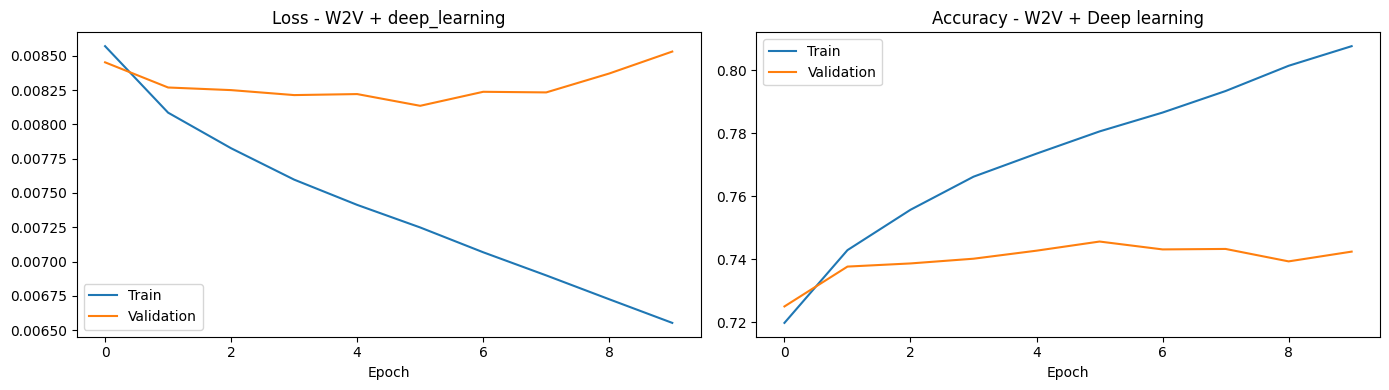

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(hist_train_loss_deep_learning, label='Train')
axes[0].plot(hist_test_loss_deep_learning, label='Validation')
axes[0].set_title('Loss - W2V + deep_learning')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(hist_train_acc_deep_learning, label='Train')
axes[1].plot(hist_test_acc_deep_learning, label='Validation')
axes[1].set_title('Accuracy - W2V + Deep learning')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [53]:
model_deep_learning.eval()
with torch.no_grad():
    predictions_deep_learning = model_deep_learning(torch.FloatTensor(np.float32(X_test))).numpy()

predictions_deep_learning_hot = np.where(predictions_deep_learning > 0.5, 1, 0)

print("Matrice de confusion :")
print(confusion_matrix(y_test, predictions_deep_learning_hot))

print("\nRapport de classification :")
print(classification_report(y_test, predictions_deep_learning_hot))

deep_learning_accuracy = accuracy_score(y_test, predictions_deep_learning_hot)
print(f"Accuracy W2V + Deep learning : {deep_learning_accuracy:.4f}")

Matrice de confusion :
[[7509 2456]
 [2695 7340]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.74      0.75      0.74      9965
           1       0.75      0.73      0.74     10035

    accuracy                           0.74     20000
   macro avg       0.74      0.74      0.74     20000
weighted avg       0.74      0.74      0.74     20000

Accuracy W2V + Deep learning : 0.7425


---
# Partie 2 : RNN avec Embeddings

## Pourquoi le RNN ?

Avec le mean pooling, nous **perdons l'ordre** des mots :
- "Le film n'est **pas** bon" → même représentation que "Le film est **pas** non bon"

Le RNN traite la séquence de mots **dans l'ordre**, ce qui lui permet de capturer :
- La négation : "**pas** content"
- Le contexte : "c'est **vraiment** super"
- Les dépendances longue distance

```
tweet :  "great"  →  "movie"  →  "loved"  →  "it"
           ↓           ↓           ↓           ↓
RNN:    [h₁]  →   [h₂]   →   [h₃]   →   [h₄]  → classification
```

In [54]:
MAX_VOCAB_SIZE = 20000
MAX_SEQ_LEN = 50
EMBED_DIM = 300
HIDDEN_DIM = 128

# Compter tous les mots du corpus
all_words = []
for tweet in df['tweet']:
    all_words.extend(str(tweet).split())

counter = Counter(all_words)

# Construire le vocabulaire : <PAD>=0, <UNK>=1, puis les MAX_VOCAB_SIZE mots les plus fréquents
vocab = ['<PAD>', '<UNK>'] + [word for word, _ in counter.most_common(MAX_VOCAB_SIZE - 2)]
word2idx = {word: idx for idx, word in enumerate(vocab)}
VOCAB_SIZE = len(vocab)

print(f"Taille du vocabulaire : {VOCAB_SIZE}")
print(f"Mots les plus fréquents : {counter.most_common(5)}")

Taille du vocabulaire : 20000
Mots les plus fréquents : [('good', 5757), ('day', 5590), ('get', 5513), ('like', 4764), ('today', 4722)]


In [55]:
# Construire la matrice d'embedding initialisée avec Word2Vec
embed_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM))
n_found = 0

for word, idx in word2idx.items():
    if word in word2vec_model.key_to_index:
        embed_matrix[idx] = word2vec_model.get_vector(word)
        n_found += 1

print(f"Mots avec embedding pré-entraîné : {n_found}/{VOCAB_SIZE} ({100*n_found/VOCAB_SIZE:.1f}%)")

Mots avec embedding pré-entraîné : 16115/20000 (80.6%)


In [58]:
def tweet_to_sequence(tweet, word2idx, max_len):
    words = str(tweet).split()[:max_len]
    seq = [word2idx.get(word, 1) for word in words]  # 1 = <UNK>
    seq = seq + [0] * (max_len - len(seq))  # 0 = <PAD>
    return seq

In [59]:
%%time
X_seq = np.array([tweet_to_sequence(t, word2idx, MAX_SEQ_LEN) for t in df['tweet']])
print(f"Forme de X_seq : {X_seq.shape}")  # (n_samples, MAX_SEQ_LEN)

Forme de X_seq : (100000, 50)
CPU times: user 1.31 s, sys: 262 ms, total: 1.57 s
Wall time: 2.36 s


In [60]:
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq, df['label'].values, test_size=0.2, random_state=42
)
print(f"Train: {X_train_seq.shape}, Test: {X_test_seq.shape}")

Train: (80000, 50), Test: (20000, 50)


In [61]:
class SequenceDataset(Dataset):
    """
    Dataset pour les séquences de mots (indices entiers).
    """
    def __init__(self, sequences, labels):
        # LongTensor pour les indices (requis par nn.Embedding)
        self.sequences = torch.LongTensor(sequences)
        # FloatTensor avec une dimension supplémentaire pour les labels
        self.labels = torch.FloatTensor(labels).unsqueeze(1)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

In [62]:
ds_train = SequenceDataset(X_train_seq, y_train_seq)
ds_test = SequenceDataset(X_test_seq, y_test_seq)

dl_train_rnn = DataLoader(ds_train, batch_size=64, shuffle=True)
dl_test_rnn = DataLoader(ds_test, batch_size=64, shuffle=False)

In [63]:
for x, y_batch in dl_train_rnn:
    print(f"Forme X : {x.shape}, dtype : {x.dtype}")  # (64, 50) torch.int64
    print(f"Forme y : {y_batch.shape}, dtype : {y_batch.dtype}")  # (64, 1) torch.float32
    break

Forme X : torch.Size([64, 50]), dtype : torch.int64
Forme y : torch.Size([64, 1]), dtype : torch.float32


## Modèle RNN

Architecture :

```
Input (batch, 50)  ← séquences d'indices
    ↓
Embedding (batch, 50, 300)  ← nn.Embedding initialisée avec W2V
    ↓
RNN (batch, 50, 128)  ← hidden state de dimension 128
    ↓
Dernier hidden state (batch, 128)
    ↓
Linear (batch, 1)
    ↓
Sigmoid → probabilité entre 0 et 1
```

In [89]:
class SentimentRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, embed_matrix=None):
        super().__init__()

        # Couche d'embedding (padding_idx=0 pour ignorer les tokens PAD)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # Initialisation avec les vecteurs Word2Vec
        if embed_matrix is not None:
            self.embedding.weight.data.copy_(torch.FloatTensor(embed_matrix))

        # RNN : batch_first=True pour avoir (batch, seq, features)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)

        # Couche de classification
        self.fc = nn.Linear(hidden_dim, 1)

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x: (batch_size, seq_len) - indices entiers

        # Embedding : (batch_size, seq_len) → (batch_size, seq_len, embed_dim)
        embedded = self.embedding(x)

        # RNN : on récupère seulement le hidden state final
        # hidden: (num_layers=1, batch_size, hidden_dim)
        out, hidden = self.rnn(embedded)


        # torch.max sur la dimension temporelle
        pooled, _ = torch.max(out, dim=1)  # (batch, hidden_size)

        # Classifier avec pooled
        out = self.fc(pooled)
        return self.sigmoid(out)

In [90]:
model_rnn = SentimentRNN(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, embed_matrix)
print(model_rnn)

# Compter les paramètres
total_params = sum(p.numel() for p in model_rnn.parameters())
trainable_params = sum(p.numel() for p in model_rnn.parameters() if p.requires_grad)
print(f"\nTotal paramètres : {total_params:,}")
print(f"Paramètres entraînables : {trainable_params:,}")

SentimentRNN(
  (embedding): Embedding(20000, 300, padding_idx=0)
  (rnn): RNN(300, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Total paramètres : 6,055,169
Paramètres entraînables : 6,055,169


In [91]:
model_rnn.embedding.weight.requires_grad = False

In [92]:
# Compter les paramètres
total_params = sum(p.numel() for p in model_rnn.parameters())
trainable_params = sum(p.numel() for p in model_rnn.parameters() if p.requires_grad)
print(f"\nTotal paramètres : {total_params:,}")
print(f"Paramètres entraînables : {trainable_params:,}")


Total paramètres : 6,055,169
Paramètres entraînables : 55,169


In [93]:
criterion_rnn = nn.BCELoss()
optimizer_rnn = torch.optim.Adam(model_rnn.parameters(), lr=0.001)

In [94]:
model_rnn, hist_train_loss_rnn, hist_test_loss_rnn, hist_train_acc_rnn, hist_test_acc_rnn = fit(
    model_rnn, optimizer_rnn, criterion_rnn, epoch,
    dl_train_rnn, dl_test_rnn,
    number_of_good_prediction
)

Epoch 1/10 | loss: 0.0083 | val_loss: 0.0081 | acc: 0.7366 | val_acc: 0.7469
Epoch 2/10 | loss: 0.0076 | val_loss: 0.0079 | acc: 0.7650 | val_acc: 0.7526
Epoch 3/10 | loss: 0.0073 | val_loss: 0.0078 | acc: 0.7790 | val_acc: 0.7600
Epoch 4/10 | loss: 0.0070 | val_loss: 0.0077 | acc: 0.7899 | val_acc: 0.7622
Epoch 5/10 | loss: 0.0067 | val_loss: 0.0079 | acc: 0.8018 | val_acc: 0.7569
Epoch 6/10 | loss: 0.0064 | val_loss: 0.0079 | acc: 0.8129 | val_acc: 0.7588
Epoch 7/10 | loss: 0.0062 | val_loss: 0.0080 | acc: 0.8232 | val_acc: 0.7578
Epoch 8/10 | loss: 0.0059 | val_loss: 0.0083 | acc: 0.8342 | val_acc: 0.7532
Epoch 9/10 | loss: 0.0056 | val_loss: 0.0082 | acc: 0.8418 | val_acc: 0.7575
Epoch 10/10 | loss: 0.0054 | val_loss: 0.0085 | acc: 0.8531 | val_acc: 0.7548


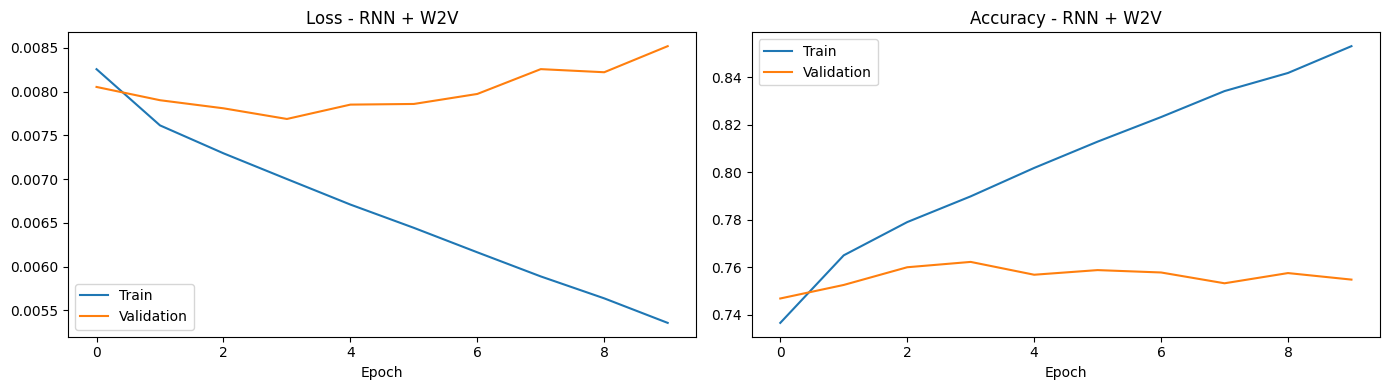

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(hist_train_loss_rnn, label='Train')
axes[0].plot(hist_test_loss_rnn, label='Validation')
axes[0].set_title('Loss - RNN + W2V')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(hist_train_acc_rnn, label='Train')
axes[1].plot(hist_test_acc_rnn, label='Validation')
axes[1].set_title('Accuracy - RNN + W2V')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [96]:
model_rnn.eval()
with torch.no_grad():
    preds_rnn = model_rnn(torch.LongTensor(X_test_seq)).numpy()

preds_rnn_hot = np.where(preds_rnn > 0.5, 1, 0)

print("Matrice de confusion :")
print(confusion_matrix(y_test_seq, preds_rnn_hot))

print("\nRapport de classification :")
print(classification_report(y_test_seq, preds_rnn_hot))

rnn_accuracy = accuracy_score(y_test_seq, preds_rnn_hot)
print(f"Accuracy RNN + W2V : {rnn_accuracy:.4f}")

Matrice de confusion :
[[7489 2476]
 [2428 7607]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.76      0.75      0.75      9965
           1       0.75      0.76      0.76     10035

    accuracy                           0.75     20000
   macro avg       0.75      0.75      0.75     20000
weighted avg       0.75      0.75      0.75     20000

Accuracy RNN + W2V : 0.7548


---
# Partie 3 : Comparaison des approches

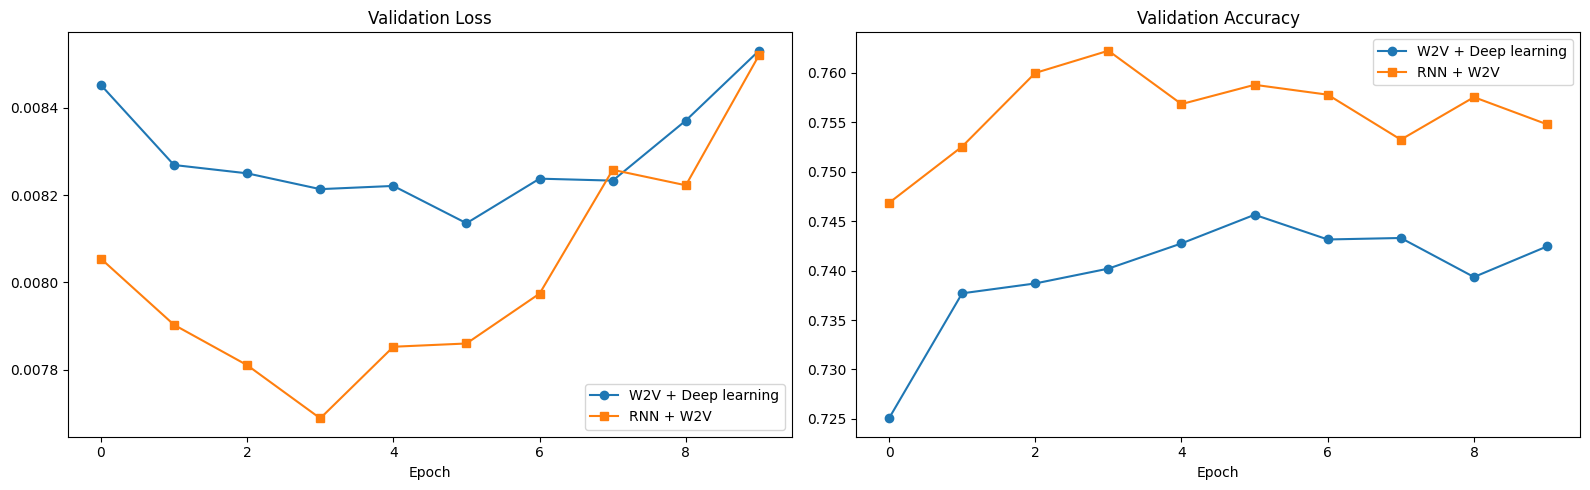

In [97]:
# Comparaison visuelle des courbes d'apprentissage
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss
axes[0].plot(hist_test_loss_deep_learning, label='W2V + Deep learning', marker='o')
axes[0].plot(hist_test_loss_rnn, label='RNN + W2V', marker='s')
axes[0].set_title('Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# Accuracy
axes[1].plot(hist_test_acc_deep_learning, label='W2V + Deep learning', marker='o')
axes[1].plot(hist_test_acc_rnn, label='RNN + W2V', marker='s')
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [98]:
print("\n" + "="*65)
print("RÉSUMÉ DE LA COMPARAISON DES APPROCHES")
print("="*65)

results = pd.DataFrame({
    'Approche': ['TF-IDF + Deep learning (notebook 23)', 'W2V Mean Pooling + Deep learning', 'RNN + W2V'],
    'Input dim': ['~14 000', '300', '50 (séquence)'],
    'Test Accuracy': ['~0.73 (référence)', f'{deep_learning_accuracy:.4f}', f'{rnn_accuracy:.4f}'],
    'Capture la sémantique': ['Non', 'Oui', 'Oui'],
    "Capture l'ordre": ['Non', 'Non', 'Oui']
})

print(results.to_string(index=False))


RÉSUMÉ DE LA COMPARAISON DES APPROCHES
                            Approche     Input dim     Test Accuracy Capture la sémantique Capture l'ordre
TF-IDF + Deep learning (notebook 23)       ~14 000 ~0.73 (référence)                   Non             Non
    W2V Mean Pooling + Deep learning           300            0.7425                   Oui             Non
                           RNN + W2V 50 (séquence)            0.7548                   Oui             Oui


## Discussion

**Observations :**

1. **W2V + Deep learning vs TF-IDF + Deep learning** : L'embedding réduit drastiquement la dimensionnalité (300 vs ~14000) tout en capturant la sémantique. Le modèle généralise mieux car il a vu des relations entre mots pendant le pré-entraînement.

2. **RNN vs Deep learning** : Le RNN capture l'ordre des mots, ce qui est crucial pour comprendre la négation ("not good" vs "good not") et le contexte. Il obtient généralement les meilleures performances.

**Pour aller plus loin :**
- RNN bidirectionnel (`bidirectional=True`) : lit la séquence dans les deux sens
- Plusieurs couches RNN (`num_layers=2`) : représentations plus abstraites
- GRU (`nn.GRU`) : moins rapide, plus de paramètres, souvent de meilleure performances similaires
- Transformers / BERT : état de l'art, attention mécanisme